# Crime Pattern Analysis in the United States using PCA and Clustering

## Project Overview
This project explores relationships between violent crime rates and urban population percentages across U.S. states using Principal Component Analysis (PCA) and clustering techniques.

The objectives are:
- Identify relationships between crime variables.
- Reduce dimensionality using PCA.
- Visualise patterns using a biplot.
- Group states with similar crime characteristics using clustering algorithms.
- Compare clustering performance using silhouette scores.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

## Dataset

The USArrests dataset contains statistics for all 50 U.S. states in 1973:

- Murder: Arrests per 100,000 residents
- Assault: Arrests per 100,000 residents
- Rape: Arrests per 100,000 residents
- UrbanPop: Percentage of the population living in urban areas

Source:
https://vincentarelbundock.github.io/Rdatasets/doc/datasets/USArrests.html

In [2]:
# Loading dataset
df = pd.read_csv("UsArrests.csv")
df.head()

,City,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


## Data Exploration

In [3]:
# Statistical description
df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [4]:
# Data types and shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   City      50 non-null     str    
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 2.1 KB


5 Features, 50 entries

In [5]:
# Missing values
df.isnull().sum()

City        0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

No missing values

In [6]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

No duplicate entries

## Correlations

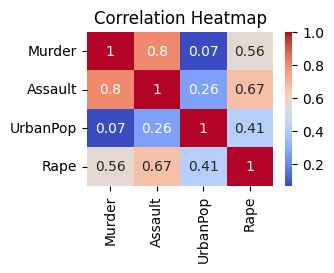

In [7]:
X = df.drop('City', axis=1)

corr = X.corr(numeric_only=True)
plt.figure(figsize = (3, 2))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Assault and Murder has a very strong correlation - 0.8.
Rape also has moderately strong correlations with Murder(0.56), Assault(0.67) and UrbanPop(0.41)

Strong Correlations between features can create redundancy within the data and overcomplicate the machine learning process.

## Data Scaling

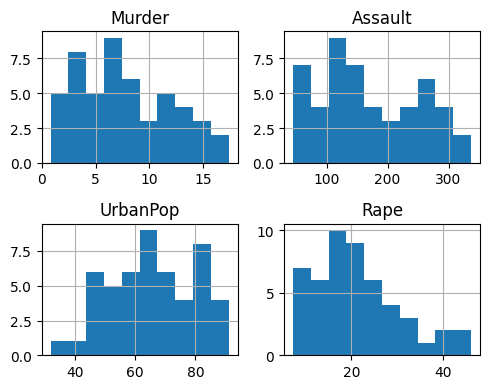

In [8]:
# Plot histograms
histograms = X.hist(figsize=(5, 4))
plt.tight_layout()
plt.show()

The features do not have normal distributions - Normalisation will be used for scaling.

In [9]:
X_values = X.values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_values)

## PCA - Principal Component Analysis

In [10]:
pca = PCA()
X_scaled_trans = pca.fit_transform(X_scaled)

X_scaled_trans = pd.DataFrame(X_scaled_trans)
X_scaled_trans.head()

,0,1,2,3
0,0.293082,-0.273177,-0.098603,-0.047938
1,0.497299,-0.225498,0.501542,0.133087
2,0.460302,0.201380,0.003031,0.223196
3,-0.006003,-0.275698,0.028729,0.050640
4,0.612016,0.409985,0.143261,0.093440


### Biplot

In [11]:
# Create biplot function
def biplot(score, coeff, labels=None, points=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())

    fig, ax = plt.subplots(figsize = (12,9))

    ax.scatter(xs * scalex,ys * scaley,s=5)

    for i in range(0,len(xs)):
        txt = Entries[i]
        ax.annotate(txt, (xs[i]* scalex, ys[i]* scaley), fontsize=8)

    for i in range(n):
        ax.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r', head_width=0.02, alpha = 0.5)
        if labels is None:
            ax.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'green', ha = 'center', va = 'center')
        else:
            ax.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid()

    # Adapted from: https://ostwalprasad.github.io/machine-learning/PCA-using-python.html

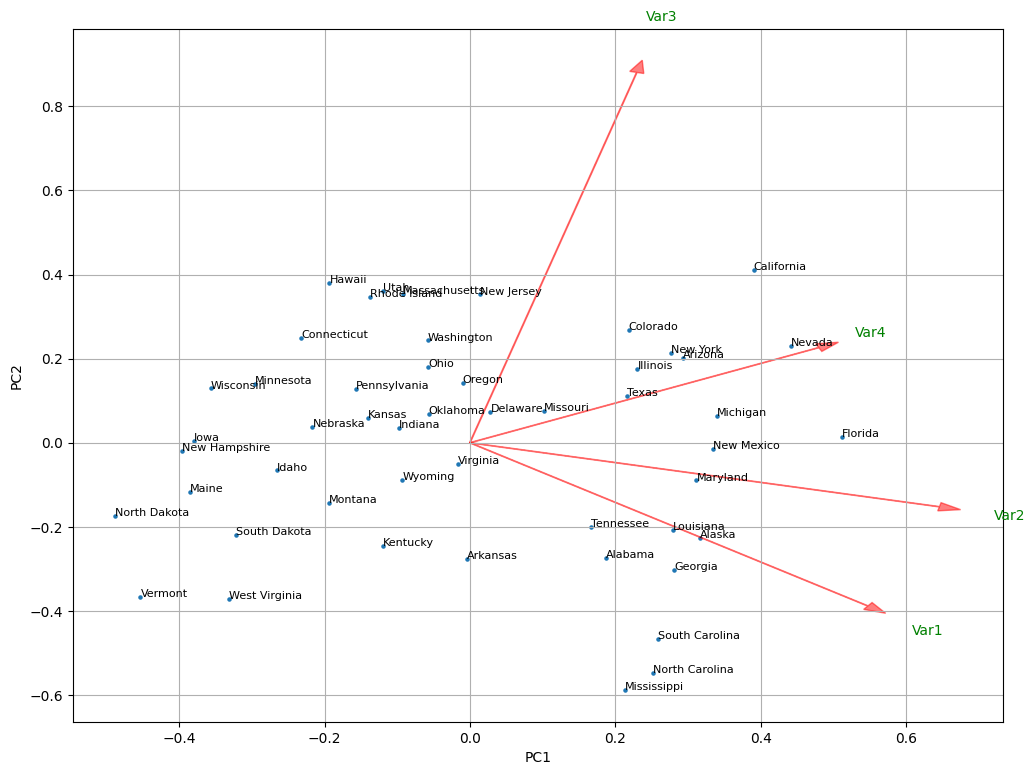

In [12]:
# Plotting the biplot.
Entries = df["City"]

biplot(X_scaled_trans.iloc[:, 0:2].to_numpy(),
    np.transpose(pca.components_[0:2, :]))

plt.show()

### PCA Interpretation

PC1 is strongly influenced by Assault, Murder and Rape, suggesting it represents overall violent crime levels.

PC2 is influenced more heavily by UrbanPop and may represent differences in urbanisation among states.

Together, the first two principal components explain approximately 87% of the total variance, making them suitable for visualisation and clustering.

### Importance

In [13]:
# Feature importance
pc1 = abs( pca.components_[0] )
pc2 = abs( pca.components_[1] )

labels = X.columns

feat_df = pd.DataFrame()
feat_df["Features"] = list(labels)
feat_df["PC1 Importance"] = pc1
feat_df["PC2 Importance"] = pc2
feat_df

,Features,PC1 Importance,PC2 Importance
0,Murder,0.547500,0.387958
1,Assault,0.645931,0.152124
2,UrbanPop,0.229559,0.880444
3,Rape,0.479916,0.226196


### Selecting Number of principal components

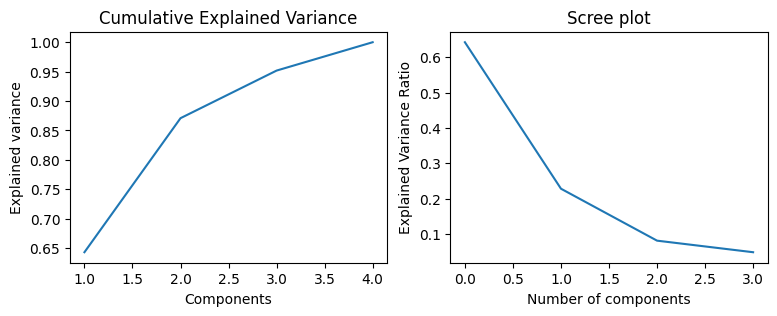

In [14]:
# Cumulative variance plot

fig, axes = plt.subplots(1, 2, figsize = (9,3))

axes[0].plot(range(1,len(pca.explained_variance_ratio_ )+1),
         np.cumsum(pca.explained_variance_ratio_))
axes[0].set_ylabel('Explained variance')
axes[0].set_xlabel('Components')
axes[0].set_title("Cumulative Explained Variance")

axes[1].plot(pca.explained_variance_ratio_)
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title("Scree plot")

plt.show()

The first 2 principal components together explain around 87% of the variance.

The first 3 principal components together explain around 95% of the variance.

In [15]:
# Extract first 2 and 3 and principal components for further analysis
pca_2_df = pd.DataFrame(X_scaled_trans.iloc[:,0:2])
pca_3_df = pd.DataFrame(X_scaled_trans.iloc[:,0:3])

## Dendogram

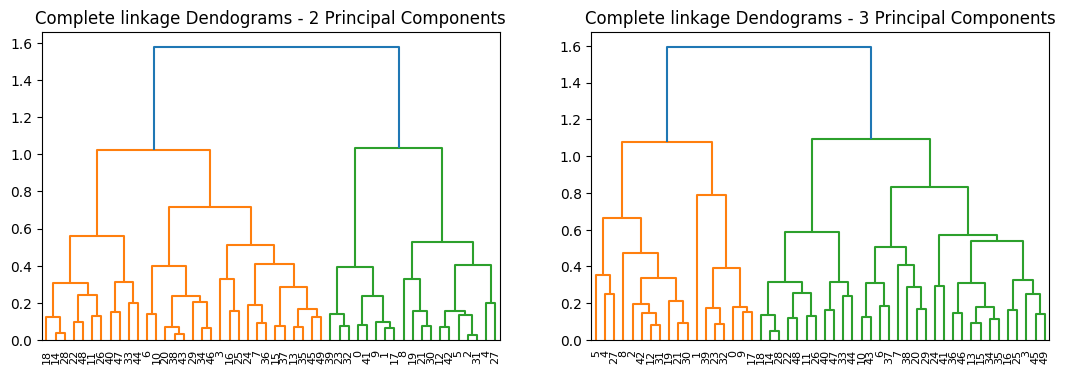

In [16]:
# Plot Dendograms (Comparing 2 and 3 principal components)

fig, axes = plt.subplots(1,2, figsize = (13,4))

axes[0].set_title("Complete linkage Dendograms - 2 Principal Components")
dend = dendrogram(linkage(pca_2_df, method='complete'), ax = axes[0])

axes[1].set_title("Complete linkage Dendograms - 3 Principal Components")
dend = dendrogram(linkage(pca_3_df, method='complete'), ax = axes[1])

## Elbow Method

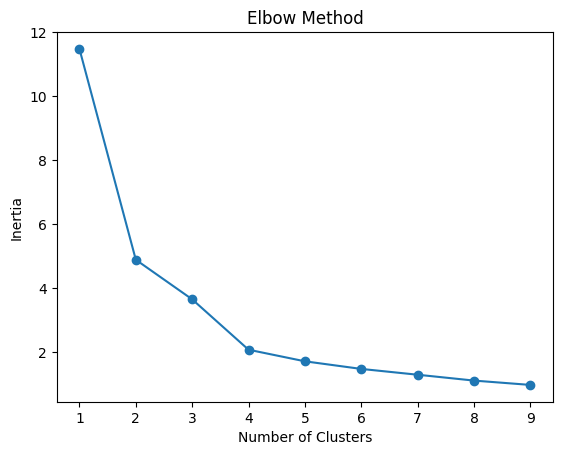

In [17]:
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(pca_2_df)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The elbow method confirms 2 clusters

## Hierarchical Clustering

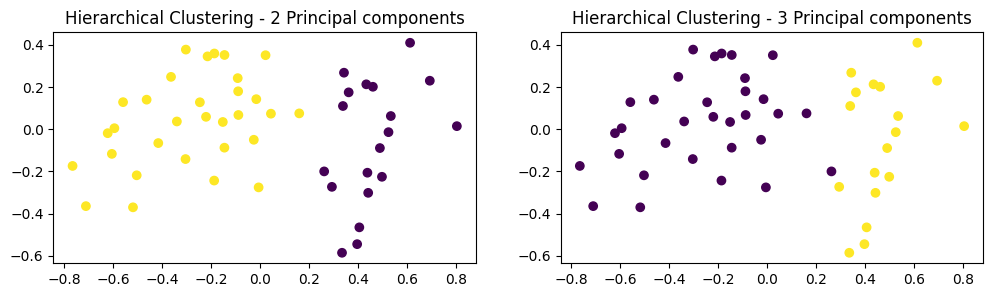

In [18]:
# Specify number of clusters based on dendogram
K = 2
type_link = 'complete'

# Initialise Agglomerative Clustering with  clusters, using Euclidean distance
# and complete linkage
cluster2 = AgglomerativeClustering(n_clusters = K, metric = 'euclidean', linkage = type_link)
cluster2.fit_predict(pca_2_df)

cluster3 = AgglomerativeClustering(n_clusters = K, metric = 'euclidean', linkage = type_link)
cluster3.fit_predict(pca_3_df)

fig, axes = plt.subplots(1, 2, figsize = (12,3))
axes[0].scatter( pca_2_df.iloc[:, 0], pca_2_df.iloc[:, 1], c = cluster2.labels_)
axes[1].scatter( pca_3_df.iloc[:, 0], pca_3_df.iloc[:, 1], c = cluster3.labels_)
axes[0].set_title("Hierarchical Clustering - 2 Principal components")
axes[1].set_title("Hierarchical Clustering - 3 Principal components")
plt.show()

## K-means Clustering

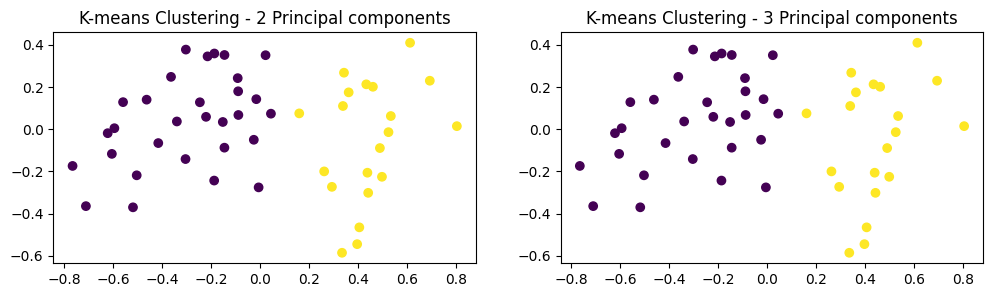

In [19]:
# Specify number of clusters based on dendogram
K = 2

# K-means clustering
kmeans2 = KMeans(n_clusters = K, random_state = 42)
kmeans_2labels = kmeans2.fit_predict(pca_2_df)

kmeans3 = KMeans(n_clusters = K, random_state = 42)
kmeans_3labels = kmeans3.fit_predict(pca_3_df)

fig, axes = plt.subplots(1, 2, figsize = (12,3))
axes[0].scatter( pca_2_df.iloc[:, 0], pca_2_df.iloc[:, 1], c = kmeans_2labels)
axes[1].scatter( pca_3_df.iloc[:, 0], pca_3_df.iloc[:, 1], c = kmeans_3labels)
axes[0].set_title("K-means Clustering - 2 Principal components")
axes[1].set_title("K-means Clustering - 3 Principal components")
plt.show()

## Compare clustering methods

### Silhouette Score

In [20]:
# Silhouette Score
# 2 Principal components

sil_kmeans2 = silhouette_score(pca_2_df, kmeans_2labels)
sil_hc2 = silhouette_score(pca_2_df, cluster2.labels_)

print(f"Silhouette Score for K-means clustering using 2 Principal components: {sil_kmeans2:.4f}\n"
f"Silhouette Score for hierarchical clustering using 2 Principal components: {sil_hc2:.4f}")

Silhouette Score for K-means clustering using 2 Principal components: 0.4915
Silhouette Score for hierarchical clustering using 2 Principal components: 0.4882


In [21]:
# Silhouette Score
# 3 Principal components

sil_kmeans3 = silhouette_score(pca_3_df, kmeans_3labels)
sil_hc3 = silhouette_score(pca_3_df, cluster3.labels_)

print(f"Silhouette Score for K-means clustering using 3 Principal components: {sil_kmeans3:.4f}\n"
f"Silhouette Score for hierarchical clustering using 3 Principal components: {sil_hc3:.4f}")

Silhouette Score for K-means clustering using 3 Principal components: 0.4483
Silhouette Score for hierarchical clustering using 3 Principal components: 0.4278


In [22]:
results = pd.DataFrame({
    "Method": [
        "K-Means (2 PCs)",
        "Hierarchical (2 PCs)",
        "K-Means (3 PCs)",
        "Hierarchical (3 PCs)"
    ],
    "Silhouette Score": [
        sil_kmeans2,
        sil_hc2,
        sil_kmeans3,
        sil_hc3
    ]
})

results.sort_values("Silhouette Score", ascending=False)

,Method,Silhouette Score
0,K-Means (2 PCs),0.491468
1,Hierarchical (2 PCs),0.488203
2,K-Means (3 PCs),0.448322
3,Hierarchical (3 PCs),0.427827


### Winner: K-means clustering with 2 principal components 
Silhouette score: 0.4915

## Interpreting results

In [23]:
# Adding cluster labels to dataframe
df["cluster"] = kmeans_2labels

# Mean statistics per cluster
df.groupby("cluster").mean(numeric_only=True)

,Murder,Assault,UrbanPop,Rape
cluster,,,,
0,4.870,114.433333,63.633333,15.943333
1,12.165,255.250000,68.400000,29.165000


The mean statistics per cluster indicate that cities in Cluster 1 experience significantly higher levels of violence, with greater average rates of murder, assault, and rape compared to Cluster 0. The main factor driving the separation between the clusters appears to be assault, which shows the largest difference in mean values across groups.

# Conclusion

Key findings:

- Assault and Murder show a strong positive correlation.
- The first two principal components capture approximately 87% of dataset variance.
- PCA successfully reduces dimensionality while retaining most information.
- K-Means clustering on the first two principal components achieved the highest silhouette score (0.49).
- States naturally separate into lower-crime and higher-crime groups.

This demonstrates how PCA and clustering can uncover hidden patterns in multivariate crime data.